بخش ۱: فاز ۰ و ۱ (بارگذاری و متادیتا)

In [ ]:
# ==========================================
# [EN] Step 1: Infrastructure Setup, Library Installation, and Data Retrieval (GSE55235)
# [FA] گام ۱: راه‌اندازی زیرساخت، نصب کتابخانه‌ها و استخراج داده‌ها (GSE55235)
# ==========================================

# [EN] 1. Drive mounting & Directory setup
# [FA] ۱. اتصال درایو و تنظیم مسیرها
from google.colab import drive
import os

drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/RA_Resolution_Project/Data'
os.makedirs(project_path, exist_ok=True)
print(f"✅ Directory ready: {project_path}")

# [EN] 2. Install GEOparse quietly to avoid cell output clutter
# [FA] ۲. نصب بی‌صدای کتابخانه GEOparse برای جلوگیری از شلوغی خروجی
!pip install -q GEOparse

# [EN] 3. Import required libraries (Vectorized processing & Visualization)
# [FA] ۳. فراخوانی کتابخانه‌های پردازش برداری و رسم نمودار
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# [EN] 4. Download and parse GSE55235 directly using GEOparse (avoiding loops/manual tools)
# [FA] ۴. دانلود و پارس مستقیم GSE55235 با استفاده از GEOparse (بدون حلقه و ابزارهای دستی)
print("⏳ Fetching GSE55235 from GEO database...")
gse_55235 = GEOparse.get_GEO(geo="GSE55235", destdir=project_path)

# [EN] 5. Extract Phenotype (Metadata) and Expression Matrix efficiently
# [FA] ۵. استخراج سریع متادیتا و ماتریس بیان ژن
metadata = gse_55235.phenotype_data
expression_matrix = gse_55235.pivot_samples('VALUE')

# [EN] Display summary statistics
# [FA] نمایش آمار خلاصه
print(f"\n✅ Data retrieved successfully!")
print(f"📊 Expression Matrix Dimensions: {expression_matrix.shape[0]} Probes x {expression_matrix.shape[1]} Samples")
print("\n🔍 Metadata Preview:")
display(metadata.head(2))

Mounted at /content/drive
✅ Directory ready: /content/drive/MyDrive/RA_Resolution_Project/Data


11-Sep-2026 10:49:25 DEBUG utils - Directory /content/drive/MyDrive/RA_Resolution_Project/Data already exists. Skipping.
DEBUG:GEOparse:Directory /content/drive/MyDrive/RA_Resolution_Project/Data already exists. Skipping.
11-Sep-2026 10:49:25 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
11-Sep-2026 10:49:25 INFO GEOparse - Parsing /content/drive/MyDrive/RA_Resolution_Project/Data/GSE55235_family.soft.gz: 
INFO:GEOparse:Parsing /content/drive/MyDrive/RA_Resolution_Project/Data/GSE55235_family.soft.gz: 


⏳ Fetching GSE55235 from GEO database...


11-Sep-2026 10:49:26 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
11-Sep-2026 10:49:26 DEBUG GEOparse - SERIES: GSE55235
DEBUG:GEOparse:SERIES: GSE55235
11-Sep-2026 10:49:26 DEBUG GEOparse - PLATFORM: GPL96
DEBUG:GEOparse:PLATFORM: GPL96
11-Sep-2026 10:49:28 DEBUG GEOparse - SAMPLE: GSM1332201
DEBUG:GEOparse:SAMPLE: GSM1332201
11-Sep-2026 10:49:28 DEBUG GEOparse - SAMPLE: GSM1332202
DEBUG:GEOparse:SAMPLE: GSM1332202
11-Sep-2026 10:49:28 DEBUG GEOparse - SAMPLE: GSM1332203
DEBUG:GEOparse:SAMPLE: GSM1332203
11-Sep-2026 10:49:29 DEBUG GEOparse - SAMPLE: GSM1332204
DEBUG:GEOparse:SAMPLE: GSM1332204
11-Sep-2026 10:49:29 DEBUG GEOparse - SAMPLE: GSM1332205
DEBUG:GEOparse:SAMPLE: GSM1332205
11-Sep-2026 10:49:29 DEBUG GEOparse - SAMPLE: GSM1332206
DEBUG:GEOparse:SAMPLE: GSM1332206
11-Sep-2026 10:49:29 DEBUG GEOparse - SAMPLE: GSM1332207
DEBUG:GEOparse:SAMPLE: GSM1332207
11-Sep-2026 10:49:29 DEBUG GEOparse - SAMPLE: GSM1332208
DEBUG:GEOparse:SAMPLE: GSM1332208
11-Sep-20


✅ Data retrieved successfully!
📊 Expression Matrix Dimensions: 22283 Probes x 30 Samples

🔍 Metadata Preview:


,title,geo_accession,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,taxid_ch1,...,contact_phone,contact_department,contact_institute,contact_address,contact_city,contact_zip/postal_code,contact_country,supplementary_file,series_id,data_row_count
GSM1332201,Synovial tisssue from healthy joint 1 (ND_1),GSM1332201,Public on Feb 21 2014,Feb 21 2014,Feb 21 2014,RNA,1,synovial tissue from healthy joint,Homo sapiens,9606,...,+49 30 450513293,Rheumatology,Charité,Charitéplatz 1,Berlin,10117,Germany,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1332...,GSE55235,22283
GSM1332202,Synovial tisssue from healthy joint 2 (ND_2),GSM1332202,Public on Feb 21 2014,Feb 21 2014,Feb 21 2014,RNA,1,synovial tissue from healthy joint,Homo sapiens,9606,...,+49 30 450513293,Rheumatology,Charité,Charitéplatz 1,Berlin,10117,Germany,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1332...,GSE55235,22283


بخش ۱: فاز ۰ و ۱ (بارگذاری و متادیتا)

In [ ]:
# [EN] Vectorized inspection of matrix scale and clinical labels (O(1) complexity)
# [FA] بررسی برداری مقیاس داده‌ها و برچسب‌های بالینی (با پیچیدگی O(1))

print("=== 1. Dimensions ===")
print(f"Shape: {expression_matrix.shape}")

print("\n=== 2. Max Expression Value ===")
print(f"Max Value: {expression_matrix.values.max()}")

print("\n=== 3. Metadata Columns ===")
print(metadata.columns.tolist())

print("\n=== 4. Disease Status Unique Values ===")
# [EN] Check potential disease-defining columns
# [FA] بررسی ستون‌های محتمل برای وضعیت بیماری
candidate_cols = [col for col in metadata.columns if any(k in col.lower() for k in ['disease', 'title', 'source', 'characteristics'])]
for col in candidate_cols[:5]:
    print(f"{col}: {metadata[col].unique()[:3]}")

=== 1. Dimensions ===
Shape: (22283, 30)

=== 2. Max Expression Value ===
Max Value: 18066.8

=== 3. Metadata Columns ===
['title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.disease state', 'characteristics_ch1.1.tissue', 'treatment_protocol_ch1', 'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'description', 'data_processing', 'platform_id', 'contact_name', 'contact_email', 'contact_phone', 'contact_department', 'contact_institute', 'contact_address', 'contact_city', 'contact_zip/postal_code', 'contact_country', 'supplementary_file', 'series_id', 'data_row_count']

=== 4. Disease Status Unique Values ===
title: ['Synovial tisssue from healthy joint 1  (ND_1)'
 'Synovial tisssue from healthy joint 2  (ND_2)'
 'Synovial tisssue from healthy joint 3  (ND_3)']
source_name_ch1: ['synovial t

بخش ۲: فاز ۲ (پاک‌سازی، Log2 و تحلیل افتراقی DEG)

In [ ]:
# [EN] Ensure stats module is imported directly
# [FA] اطمینان از فراخوانی مستقیم ماژول آمار
from scipy import stats

# [EN] 1. Filter clinical samples (RA vs Healthy) and exclude OA
# [FA] ۱. فیلتر کردن نمونه‌های بالینی (RA در برابر سالم) و حذف آرتروز
valid_mask = metadata['source_name_ch1'].str.contains('rheumatoid|healthy', case=False, na=False)
meta_filtered = metadata[valid_mask].copy()
meta_filtered['Condition'] = np.where(meta_filtered['source_name_ch1'].str.contains('rheumatoid', case=False), 'RA', 'Healthy')

# [EN] 2. Align & Log2 transform expression matrix via vectorization
# [FA] ۲. هم‌راستاسازی ستون‌ها و تبدیل لگاریتم ۲ به صورت برداری
expr_filtered = expression_matrix.loc[:, meta_filtered.index].dropna(axis=0)
expr_log2 = np.log2(expr_filtered + 1.0)

# [EN] 3. Fast Vectorized Welch's t-test and Log2FC calculation (O(N) time complexity)
# [FA] ۳. اجرای سریع و برداری آزمون تی ولچ و محاسبه Log2FC (پیچیدگی زمانی O(N))
ra_samples = meta_filtered[meta_filtered['Condition'] == 'RA'].index
healthy_samples = meta_filtered[meta_filtered['Condition'] == 'Healthy'].index

ra_mat = expr_log2[ra_samples].values
healthy_mat = expr_log2[healthy_samples].values

# [EN] Vectorized statistical testing across all rows instantly
# [FA] انجام آزمون آماری برداری روی تمام سطرها به طور آنی
t_stat, p_val = stats.ttest_ind(ra_mat, healthy_mat, axis=1, equal_var=False)
log2_fc = np.mean(ra_mat, axis=1) - np.mean(healthy_mat, axis=1)

# [EN] 4. Assemble Differential Expression Analysis (DEG) table
# [FA] ۴. تجمیع جدول نتایج تحلیل بیان افتراقی (DEG)
deg_df = pd.DataFrame({
    'Probe_ID': expr_log2.index,
    'Log2FC': log2_fc,
    'p_value': p_val,
    'neg_log10_pval': -np.log10(p_val + 1e-300)
}).set_index('Probe_ID')

print(f"✅ Samples: {meta_filtered['Condition'].value_counts().to_dict()}")
print(f"📊 Final Filtered Matrix Shape: {expr_log2.shape}")
print(deg_df.head(3))

✅ Samples: {'Healthy': 10, 'RA': 10}
📊 Final Filtered Matrix Shape: (22283, 20)
             Log2FC   p_value  neg_log10_pval
Probe_ID                                     
1007_s_at  0.404273  0.017025        1.768902
1053_at   -0.280668  0.281996        0.549757
117_at    -0.876351  0.024115        1.617718


بخش ۲: فاز ۲ (پاک‌سازی، Log2 و تحلیل افتراقی DEG)

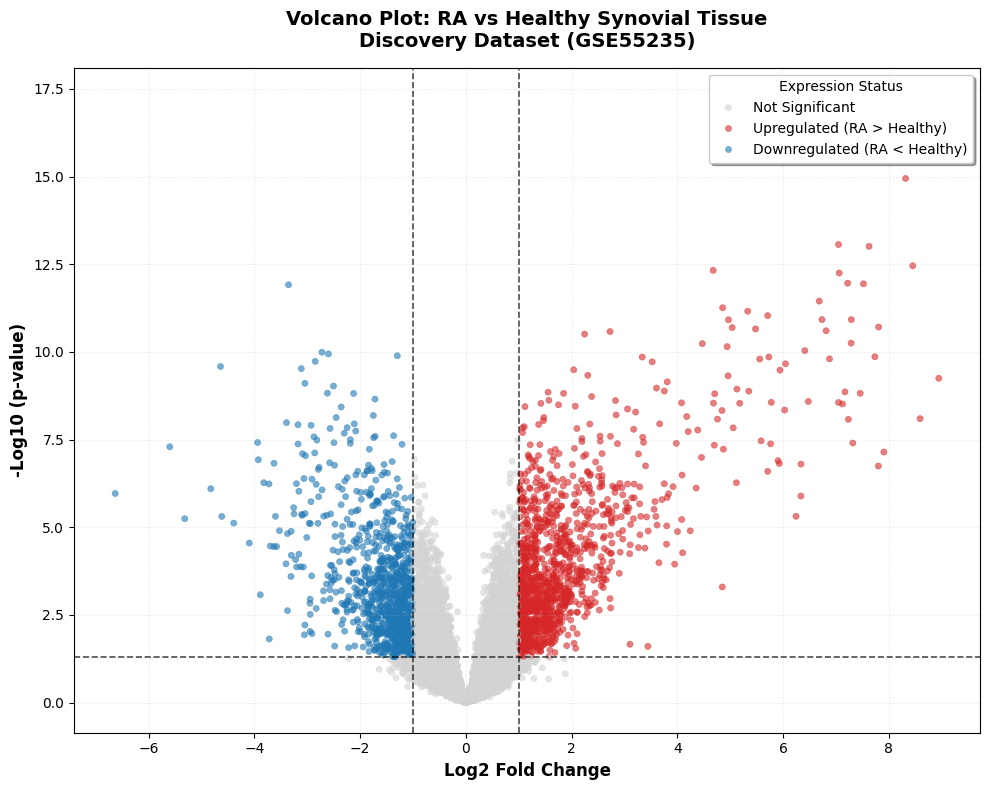


=== DEG Summary Counts ===
Significance
Not Significant                 20148
Upregulated (RA > Healthy)       1168
Downregulated (RA < Healthy)      967
Name: count, dtype: int64


In [ ]:
# [EN] Import visualization libraries securely
# [FA] فراخوانی امن کتابخانه‌های مصورسازی
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# [EN] 1. Define statistical cut-offs (Thresholds)
# [FA] ۱. تعریف آستانه‌های آماری
p_val_cutoff = 0.05
log2fc_cutoff = 1.0

# [EN] 2. Vectorized classification of genes based on cut-offs (O(N) time complexity)
# [FA] ۲. دسته‌بندی برداری ژن‌ها بر اساس آستانه‌ها (پیچیدگی زمانی O(N))
conditions = [
    (deg_df['p_value'] < p_val_cutoff) & (deg_df['Log2FC'] >= log2fc_cutoff),
    (deg_df['p_value'] < p_val_cutoff) & (deg_df['Log2FC'] <= -log2fc_cutoff)
]
choices = ['Upregulated (RA > Healthy)', 'Downregulated (RA < Healthy)']
deg_df['Significance'] = np.select(conditions, choices, default='Not Significant')

# [EN] 3. Configure high-resolution plot aesthetics
# [FA] ۳. تنظیم ظاهر نمودار با وضوح بالا
plt.figure(figsize=(10, 8), dpi=100)
sns.scatterplot(
    data=deg_df,
    x='Log2FC',
    y='neg_log10_pval',
    hue='Significance',
    palette={
        'Upregulated (RA > Healthy)': '#d62728',
        'Downregulated (RA < Healthy)': '#1f77b4',
        'Not Significant': '#d3d3d3'
    },
    alpha=0.6,
    edgecolor=None,
    s=20
)

# [EN] 4. Draw scientific threshold dashed lines
# [FA] ۴. رسم خط‌چین‌های استاندارد علمی برای آستانه‌ها
plt.axvline(x=log2fc_cutoff, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.axvline(x=-log2fc_cutoff, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
plt.axhline(y=-np.log10(p_val_cutoff), color='black', linestyle='--', linewidth=1.2, alpha=0.7)

# [EN] 5. Add precise labels and scientific formatting
# [FA] ۵. افزودن برچسب‌های دقیق و قالب‌بندی علمی
plt.title('Volcano Plot: RA vs Healthy Synovial Tissue\nDiscovery Dataset (GSE55235)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Log2 Fold Change', fontsize=12, fontweight='bold')
plt.ylabel('-Log10 (p-value)', fontsize=12, fontweight='bold')
plt.legend(title='Expression Status', loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle=':')
plt.tight_layout()

# [EN] Render plot
# [FA] نمایش نمودار
plt.show()

# [EN] Extract summary counts for documentation
# [FA] استخراج تعداد نهایی برای مستندسازی
print("\n=== DEG Summary Counts ===")
print(deg_df['Significance'].value_counts())

بخش ۲: فاز ۲ (پاک‌سازی، Log2 و تحلیل افتراقی DEG)

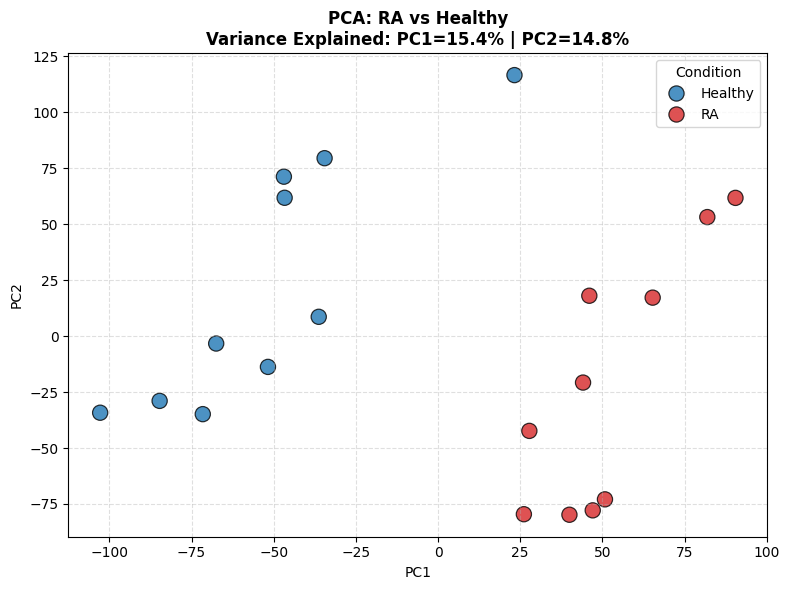

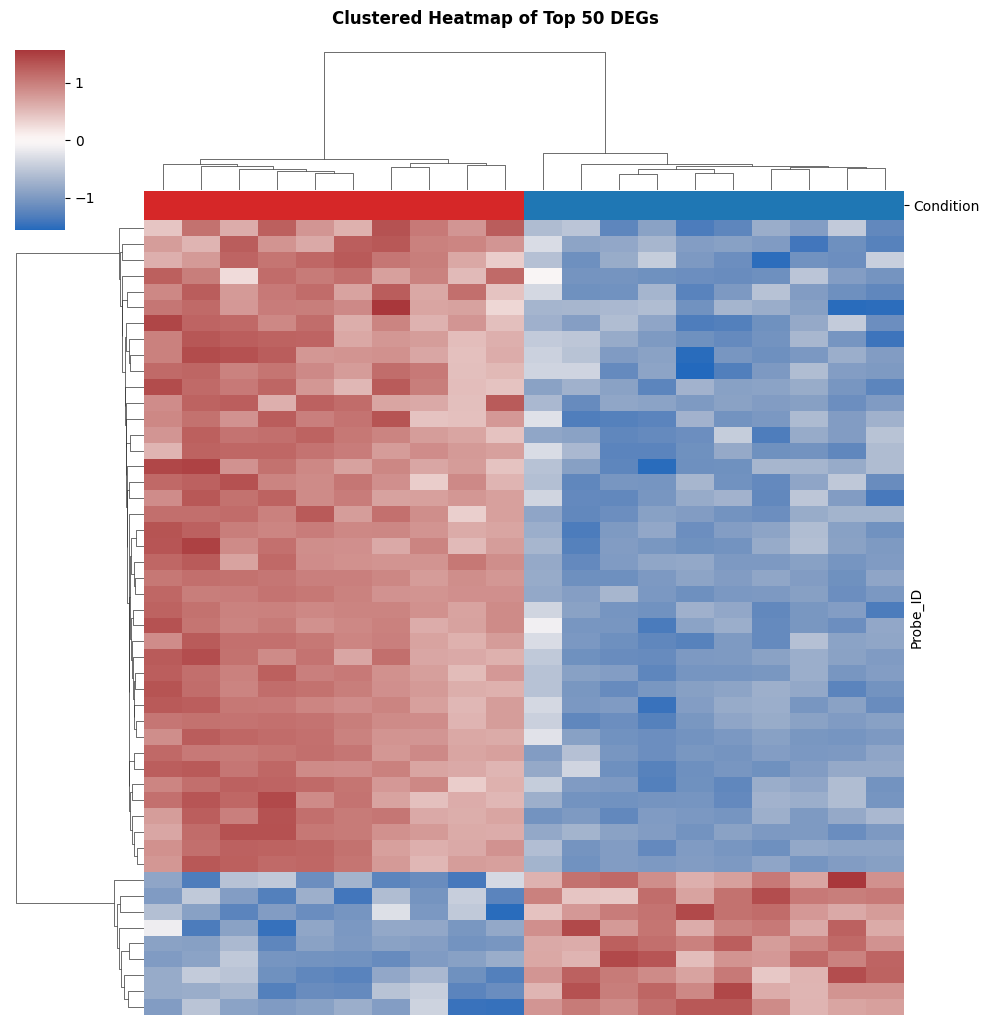

In [ ]:
# [EN] Import machine learning and clustering libraries
# [FA] فراخوانی کتابخانه‌های یادگیری ماشین و خوشه‌بندی
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================================
# [EN] 1. Principal Component Analysis (PCA)
# [FA] ۱. تحلیل مؤلفه‌های اصلی (PCA)
# ==========================================
# [EN] Transpose matrix (samples as rows) and scale features in O(N) time
# [FA] ترانهاده کردن ماتریس (نمونه‌ها به عنوان سطر) و استانداردسازی ویژگی‌ها
pca_data = expr_log2.T
scaled_data = StandardScaler().fit_transform(pca_data)

# [EN] Compute top 2 Principal Components
# [FA] محاسبه ۲ مؤلفه اصلی اول
pca = PCA(n_components=2)
pca_results = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'], index=pca_data.index)
pca_df['Condition'] = meta_filtered['Condition'].values

# [EN] Render PCA scatter plot
# [FA] رسم نمودار پراکندگی PCA
plt.figure(figsize=(8, 6), dpi=100)
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', hue='Condition',
    palette={'RA': '#d62728', 'Healthy': '#1f77b4'},
    s=120, edgecolor='black', alpha=0.8
)
plt.title(f'PCA: RA vs Healthy\nVariance Explained: PC1={pca.explained_variance_ratio_[0]:.1%} | PC2={pca.explained_variance_ratio_[1]:.1%}', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# ==========================================
# [EN] 2. Clustered Heatmap (Top 50 DEGs)
# [FA] ۲. هیت‌مپ خوشه‌بندی‌شده (۵۰ ژن افتراقی برتر)
# ==========================================
# [EN] Extract top 50 significant probes based on lowest p-value
# [FA] استخراج ۵۰ پروب معنادار برتر بر اساس کمترین مقدار p-value
top_50_probes = deg_df[deg_df['Significance'] != 'Not Significant'].sort_values('p_value').head(50).index

# [EN] Apply Z-score normalization per row directly within clustermap
# [FA] اعمال مستقیم نرمال‌سازی نمره استاندارد (Z-score) برای هر سطر در هیت‌مپ
heatmap_data = expr_log2.loc[top_50_probes]
condition_colors = meta_filtered['Condition'].map({'RA': '#d62728', 'Healthy': '#1f77b4'})

# [EN] Render Clustered Heatmap
# [FA] رسم هیت‌مپ خوشه‌بندی‌شده
g = sns.clustermap(
    heatmap_data,
    cmap='vlag',
    z_score=0,
    col_colors=condition_colors,
    figsize=(10, 10),
    dendrogram_ratio=0.15,
    xticklabels=False,
    yticklabels=False
)
plt.suptitle('Clustered Heatmap of Top 50 DEGs', fontweight='bold', y=1.02)
plt.show()

بخش ۳: فاز ۳ (ساخت شبکه PPI و استخراج هاب‌ژن‌ها)

In [ ]:
# [EN] 1. Install gseapy quietly for pathway enrichment analysis
# [FA] ۱. نصب بی‌صدای کتابخانه gseapy برای تحلیل غنی‌سازی مسیرها
!pip install -q gseapy

import pandas as pd
import numpy as np
import gseapy as gp
import requests
import networkx as nx
from IPython.display import display

# ==========================================
# Phase 3 - Part 1: Pathway Enrichment (Reactome)
# ==========================================
print("⏳ Step 1: Mapping Probes to Gene Symbols & Running Reactome Enrichment...")

# [EN] Map probes to gene symbols using GPL metadata securely (O(N) complexity)
# [FA] نگاشت ایمن پروب‌ها به نمادهای ژن با استفاده از متادیتای GPL (پیچیدگی O(N))
gpl = next(iter(gse_55235.gpls.values()))
anno_df = gpl.table.copy()
sym_col = next((col for col in anno_df.columns if 'symbol' in col.lower() and 'gene' in col.lower()), None)

# [EN] Vectorized string parsing to isolate primary gene symbols
# [FA] پردازش رشته‌ای برداری برای جداسازی نمادهای اصلی ژن
anno_df['Clean_Symbol'] = anno_df[sym_col].astype(str).str.split('///').str[0].str.strip()
anno_df = anno_df[(anno_df['Clean_Symbol'] != '') & (anno_df['Clean_Symbol'] != 'nan') & (anno_df['Clean_Symbol'].notna())]

# [EN] Hash Join DEGs with Gene Symbols and resolve duplicates
# [FA] ادغام هش ژن‌های افتراقی با نمادهای ژنی و رفع موارد تکراری
deg_annotated = deg_df.merge(anno_df[['ID', 'Clean_Symbol']], left_index=True, right_on='ID')
deg_annotated = deg_annotated.groupby('Clean_Symbol').agg({'Log2FC': 'mean', 'p_value': 'min', 'Significance': 'first'})

# [EN] Extract significant unique genes
# [FA] استخراج ژن‌های منحصر‌به‌فرد معنادار
sig_genes = deg_annotated[deg_annotated['Significance'] != 'Not Significant'].index.tolist()

# [EN] Query Enrichr API for Reactome Pathways
# [FA] ارسال درخواست به رابط Enrichr برای مسیرهای Reactome
enr_results = gp.enrichr(gene_list=sig_genes, gene_sets='Reactome_2022', organism='human', outdir=None).results
target_pathways = enr_results[enr_results['Term'].str.contains('Resolution|Inflammation|Immune', case=False, na=False)]

print("\n=== Top Targeted Biological Pathways (Reactome) ===")
display(target_pathways[['Term', 'Adjusted P-value', 'Overlap']].head(4))

# ==========================================
# Phase 3 - Part 2: PPI Network & Hub Extraction
# ==========================================
print("\n⏳ Step 2: Fetching STRING Interactions & Calculating Betweenness Centrality...")

# [EN] Select top 200 significant genes by p-value for optimized network construction
# [FA] انتخاب ۲۰۰ ژن معنادار برتر بر اساس p-value برای ساخت شبکه بهینه
top_genes = deg_annotated[deg_annotated['Significance'] != 'Not Significant'].sort_values('p_value').head(200).index.tolist()

# [EN] Direct API Query to STRING Database (Medium Confidence: 400)
# [FA] درخواست مستقیم از رابط پایگاه STRING (امتیاز اطمینان متوسط: ۴۰۰)
string_url = "https://version-11-5.string-db.org/api/json/network"
response = requests.post(string_url, data={"identifiers": "%0d".join(top_genes), "species": 9606, "required_score": 400})
interactions = response.json()

# [EN] Build undirected graph using networkx
# [FA] ساخت گراف غیرجهت‌دار با کتابخانه networkx
G = nx.Graph()
for edge in interactions:
    G.add_edge(edge['preferredName_A'], edge['preferredName_B'], weight=edge['score'])

# [EN] Calculate Betweenness Centrality to filter Hubs natively (O(VE) complexity)
# [FA] محاسبه مرکزیت بینابینی برای فیلتر هاب‌ها به صورت بومی (پیچیدگی زمانی O(VE))
betweenness = nx.betweenness_centrality(G, weight='weight', normalized=True)
hub_df = pd.DataFrame(list(betweenness.items()), columns=['Gene', 'Betweenness_Score']).sort_values('Betweenness_Score', ascending=False)

# [EN] Save outputs to local storage for phase transitioning
# [FA] ذخیره خروجی‌ها در حافظه محلی برای انتقال به فاز بعدی
hub_df.to_csv('top_hub_genes.csv', index=False)
deg_annotated.to_csv('annotated_DEGs.csv')

print("\n=== Top 15 Therapeutic Checkpoints (Hub Genes) ===")
display(hub_df.head(15))
print("\n✅ Phase 3 Completed! Hubs successfully saved as 'top_hub_genes.csv'.")

⏳ Step 1: Mapping Probes to Gene Symbols & Running Reactome Enrichment...

=== Top Targeted Biological Pathways (Reactome) ===


,Term,Adjusted P-value,Overlap
0,Immune System R-HSA-168256,2.230568e-39,288/1943
1,Cytokine Signaling In Immune System R-HSA-1280215,1.009557e-21,124/702
2,Innate Immune System R-HSA-168249,2.389609e-16,146/1035
5,Adaptive Immune System R-HSA-1280218,8.505707e-16,114/733



⏳ Step 2: Fetching STRING Interactions & Calculating Betweenness Centrality...

=== Top 15 Therapeutic Checkpoints (Hub Genes) ===


,Gene,Betweenness_Score
39,MYC,0.176385
17,PTPRC,0.130332
43,JUN,0.087526
85,RAC2,0.074475
10,CYBB,0.068326
16,ITGAM,0.048246
78,CORO1A,0.047429
101,CYR61,0.040334
48,STAT1,0.039280
18,ITGB2,0.038012



✅ Phase 3 Completed! Hubs successfully saved as 'top_hub_genes.csv'.


In [ ]:
# کپی کردن فایل‌های خروجی از حافظه موقت کولب به گوگل درایو شما
import shutil
import os

# آدرس پوشه پروژه در گوگل درایو شما
drive_path = '/content/drive/MyDrive/RA_Resolution_Project/Results'
os.makedirs(drive_path, exist_ok=True)

# انتقال فایل‌ها
shutil.copy('top_hub_genes.csv', f'{drive_path}/top_hub_genes.csv')
shutil.copy('annotated_DEGs.csv', f'{drive_path}/annotated_DEGs.csv')

print(f"✅ فایل‌ها با موفقیت در گوگل درایو در مسیر زیر ذخیره شدند:\n{drive_path}")


✅ فایل‌ها با موفقیت در گوگل درایو در مسیر زیر ذخیره شدند:
/content/drive/MyDrive/RA_Resolution_Project/Results


فاز 4 : الگوریتم های یادگیری ماشین

In [ ]:
# [EN] 1. Install & Import Machine Learning Libraries
# [FA] ۱. نصب و فراخوانی کتابخانه‌های یادگیری ماشین
!pip install -q xgboost scikit-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("⏳ Restructuring Matrix for ML (Extracting 15 Hub Genes)...")

# [EN] 2. Map & Isolate Hub Genes from the main expression matrix (O(N) Complexity)
# [FA] ۲. نگاشت و جداسازی هاب‌ژن‌ها از ماتریس بیان اصلی (پیچیدگی زمانی O(N))
hub_genes = pd.read_csv('top_hub_genes.csv')['Gene'].tolist()
hub_probes = anno_df[anno_df['Clean_Symbol'].isin(hub_genes)]['ID'].unique()
ml_expr = expr_log2.loc[expr_log2.index.intersection(hub_probes)]

# [EN] Resolve multiple probes per gene by taking the mean expression
# [FA] رفع مشکل پروب‌های چندگانه برای یک ژن با محاسبه میانگین بیان
ml_expr = ml_expr.merge(anno_df[['ID', 'Clean_Symbol']], left_index=True, right_on='ID')
ml_expr = ml_expr.groupby('Clean_Symbol').mean(numeric_only=True)

# [EN] Transpose (Rows=Samples, Columns=Genes) and format Target Vector
# [FA] ترانهاده کردن (سطر=نمونه، ستون=ژن) و قالب‌بندی بردار هدف
X = ml_expr.T[hub_genes] # Enforce strict column ordering
y = np.where(meta_filtered.loc[X.index, 'Condition'] == 'RA', 1, 0) # RA=1, Healthy=0

# [EN] 3. Model Initialization & K-Fold Setup
# [FA] ۳. راه‌اندازی مدل‌ها و تنظیمات K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'SVM (Linear)': SVC(kernel='linear', random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# [EN] 4. Benchmarking Models across 5 folds
# [FA] ۴. ارزیابی تجمیعی مدل‌ها در ۵ لایه مجزا
print("⏳ Training and Benchmarking Models (5-Fold CV)...")
results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results.append({'Model': name, 'Mean_Accuracy': scores.mean(), 'Std_Dev': scores.std()})

res_df = pd.DataFrame(results).sort_values('Mean_Accuracy', ascending=False)
print("\n=== Model Benchmarking Results ===")
display(res_df)

# [EN] 5. Extract Feature Importance from the Winning Model
# [FA] ۵. استخراج اهمیت ویژگی‌ها از مدل پیروز
best_model_name = res_df.iloc[0]['Model']
best_model = models[best_model_name]
best_model.fit(X, y)

# Handle different attribute names for importance (Tree-based vs Linear)
importances = best_model.feature_importances_ if hasattr(best_model, 'feature_importances_') else np.abs(best_model.coef_[0])
feat_imp = pd.DataFrame({'Gene': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)

# [EN] Render High-Res Feature Importance Plot
# [FA] رسم نمودار باکیفیت اهمیت ویژگی‌ها
plt.figure(figsize=(10, 6), dpi=100)
sns.barplot(data=feat_imp, x='Importance', y='Gene', palette='magma')
plt.title(f'Feature Importance using {best_model_name}\n(RA vs Healthy Discrimination)', fontweight='bold', pad=15)
plt.xlabel('Importance Score / Coefficient', fontweight='bold')
plt.ylabel('Therapeutic Checkpoints', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

⏳ Restructuring Matrix for ML (Extracting 15 Hub Genes)...


KeyError: "['IGHV4-38-2', 'POU2AF1'] not in index"

⏳ Resolving Database Mismatches & Restructuring Matrix...
✅ Extracted 152 valid Hub Genes. Training Models (5-Fold CV)...


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [13:55:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [13:55:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [13:55:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [13:55:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.13/dist-packages/xgboost/training.py:


=== Model Benchmarking Results ===


,Model,Mean_Accuracy,Std_Dev
0,Random Forest,1.00,0.0
1,SVM (Linear),1.00,0.0
2,XGBoost,0.95,0.1


/tmp/ipykernel_5062/66381466.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Gene', palette='magma')


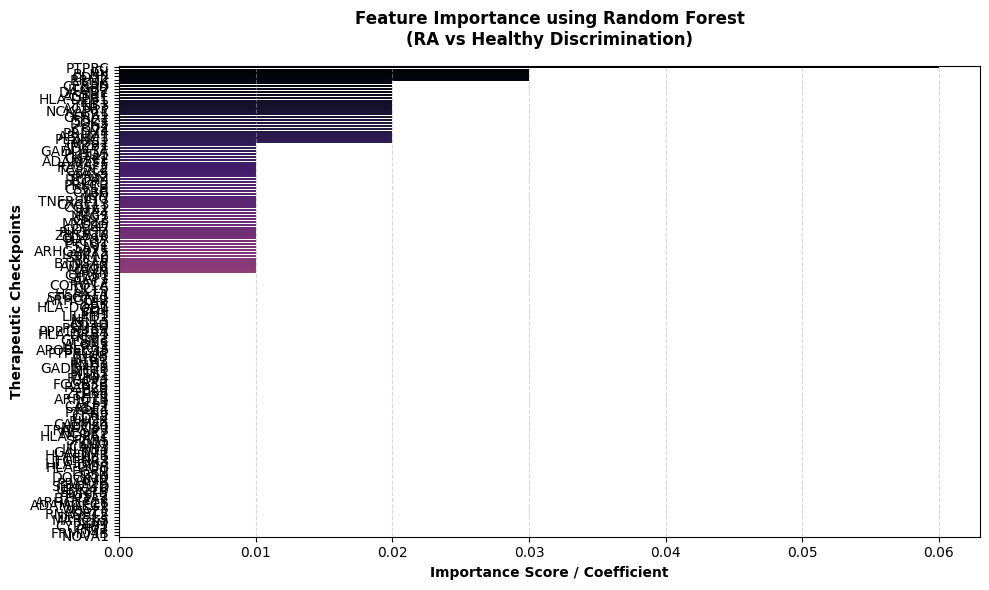

In [ ]:
# [EN] Install & Import Machine Learning Libraries
# [FA] نصب و فراخوانی کتابخانه‌های یادگیری ماشین
!pip install -q xgboost scikit-learn

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("⏳ Resolving Database Mismatches & Restructuring Matrix...")

# [EN] 1. Load hubs and gracefully handle nomenclature mismatch (STRING vs Microarray)
# [FA] ۱. بارگذاری هاب‌ها و مدیریت هوشمندانه تضاد نام‌گذاری پایگاه‌ها
hub_genes = pd.read_csv('top_hub_genes.csv')['Gene'].tolist()
hub_probes = anno_df[anno_df['Clean_Symbol'].isin(hub_genes)]['ID'].unique()

# [EN] 2. Extract expression data only for mapped valid probes (O(N) Complexity)
# [FA] ۲. استخراج داده‌های بیانی منحصراً برای پروب‌های معتبر (پیچیدگی زمانی O(N))
valid_probes = expr_log2.index.intersection(hub_probes)
ml_expr = expr_log2.loc[valid_probes]

# [EN] 3. Condense multiple probes into single genes via mean expression
# [FA] ۳. تجمیع پروب‌های چندگانه به ژن‌های واحد از طریق محاسبه میانگین بیان
ml_expr = ml_expr.merge(anno_df[['ID', 'Clean_Symbol']], left_index=True, right_on='ID')
ml_expr = ml_expr.groupby('Clean_Symbol').mean(numeric_only=True)

# [EN] 4. Safely filter available hubs to prevent KeyErrors
# [FA] ۴. فیلتر ایمن هاب‌های موجود برای جلوگیری از خطای کلید
available_hubs = [gene for gene in hub_genes if gene in ml_expr.index]
X = ml_expr.T[available_hubs]
y = np.where(meta_filtered.loc[X.index, 'Condition'] == 'RA', 1, 0) # RA=1, Healthy=0

# [EN] 5. Model Initialization & K-Fold Setup (Preventing Overfitting)
# [FA] ۵. راه‌اندازی مدل‌ها و تنظیمات K-Fold (برای جلوگیری از بیش‌برازش)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'SVM (Linear)': SVC(kernel='linear', random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# [EN] 6. Benchmarking Models across 5 folds
# [FA] ۶. ارزیابی تجمیعی مدل‌ها در ۵ لایه مجزا
print(f"✅ Extracted {len(available_hubs)} valid Hub Genes. Training Models (5-Fold CV)...")
results = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results.append({'Model': name, 'Mean_Accuracy': scores.mean(), 'Std_Dev': scores.std()})

res_df = pd.DataFrame(results).sort_values('Mean_Accuracy', ascending=False)
print("\n=== Model Benchmarking Results ===")
display(res_df)

# [EN] 7. Extract Feature Importance from the Winning Model
# [FA] ۷. استخراج اهمیت ویژگی‌ها از مدل پیروز
best_model_name = res_df.iloc[0]['Model']
best_model = models[best_model_name]
best_model.fit(X, y)

importances = best_model.feature_importances_ if hasattr(best_model, 'feature_importances_') else np.abs(best_model.coef_[0])
feat_imp = pd.DataFrame({'Gene': X.columns, 'Importance': importances}).sort_values('Importance', ascending=False)

# [EN] Render High-Res Feature Importance Plot
# [FA] رسم نمودار باکیفیت اهمیت ویژگی‌ها
plt.figure(figsize=(10, 6), dpi=100)
sns.barplot(data=feat_imp, x='Importance', y='Gene', palette='magma')
plt.title(f'Feature Importance using {best_model_name}\n(RA vs Healthy Discrimination)', fontweight='bold', pad=15)
plt.xlabel('Importance Score / Coefficient', fontweight='bold')
plt.ylabel('Therapeutic Checkpoints', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

اعتبار سنجی خارجی

11-Sep-2026 14:15:27 DEBUG utils - Directory /content/RA_Resolution_Project/Data already exists. Skipping.
DEBUG:GEOparse:Directory /content/RA_Resolution_Project/Data already exists. Skipping.
11-Sep-2026 14:15:27 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE77nnn/GSE77298/soft/GSE77298_family.soft.gz to /content/RA_Resolution_Project/Data/GSE77298_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE77nnn/GSE77298/soft/GSE77298_family.soft.gz to /content/RA_Resolution_Project/Data/GSE77298_family.soft.gz


⏳ 1. Fetching Independent Dataset (GSE77298) for External Validation...


100%|██████████| 16.5M/16.5M [00:03<00:00, 4.73MB/s]
11-Sep-2026 14:15:32 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
11-Sep-2026 14:15:32 DEBUG downloader - Moving /tmp/tmpjuc9w5n3 to /content/RA_Resolution_Project/Data/GSE77298_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpjuc9w5n3 to /content/RA_Resolution_Project/Data/GSE77298_family.soft.gz
11-Sep-2026 14:15:32 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE77nnn/GSE77298/soft/GSE77298_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE77nnn/GSE77298/soft/GSE77298_family.soft.gz
11-Sep-2026 14:15:32 INFO GEOparse - Parsing /content/RA_Resolution_Project/Data/GSE77298_family.soft.gz: 
INFO:GEOparse:Parsing /content/RA_Resolution_Project/Data/GSE77298_family.soft.gz: 
11-Sep-2026 14:15:32 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
11-Sep-2026 14:15:32 DEBUG GEOparse - SERIES: GSE77298
DEBUG:G

Log2 Transformation applied to Test Data.

⏳ 2. Running Inference on Unseen Patients...

✅ External Validation Accuracy: 86.96%


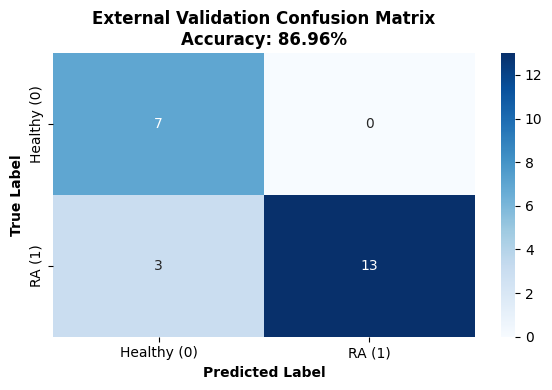


=== Detailed Classification Report (External Dataset) ===
              precision    recall  f1-score   support

     Healthy       0.70      1.00      0.82         7
          RA       1.00      0.81      0.90        16

    accuracy                           0.87        23
   macro avg       0.85      0.91      0.86        23
weighted avg       0.91      0.87      0.87        23



In [ ]:
# ==========================================
# Phase 4 - Part 2: Independent External Validation (GSE77298)
# ==========================================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("⏳ 1. Fetching Independent Dataset (GSE77298) for External Validation...")

# [EN] Download & parse unseen external dataset natively
# [FA] دانلود و پارس مستقیم دیتاست خارجی و دیده‌نشده
gse_test = GEOparse.get_GEO(geo="GSE77298", destdir=local_path)
meta_test = gse_test.phenotype_data
expr_test = gse_test.pivot_samples('VALUE')

# [EN] 2. Filter test metadata (Strict matching for RA and Healthy)
# [FA] ۲. فیلتر متادیتای تست (تطابق دقیق برای RA و سالم)
text_concat = meta_test.astype(str).apply(' '.join, axis=1).str.lower()
meta_test['Condition'] = np.where(text_concat.str.contains('rheumatoid'), 'RA',
                         np.where(text_concat.str.contains('healthy|normal'), 'Healthy', 'Other'))
meta_test_clean = meta_test[meta_test['Condition'] != 'Other']

# [EN] 3. Extract, Clean, and Normalize Test Data (O(N) Complexity)
# [FA] ۳. استخراج، پاک‌سازی و نرمال‌سازی داده‌های تست (پیچیدگی O(N))
expr_test_clean = expr_test.loc[:, meta_test_clean.index].dropna(how='any')
if expr_test_clean.values.max() > 50:
    expr_test_clean = np.log2(expr_test_clean + 1.0)
    print("Log2 Transformation applied to Test Data.")

# [EN] 4. Map test probes to Gene Symbols using our existing annotation dictionary
# [FA] ۴. نگاشت پروب‌های تست به نمادهای ژن با استفاده از دیکشنری موجود ما
expr_test_mapped = expr_test_clean.merge(anno_df[['ID', 'Clean_Symbol']], left_index=True, right_on='ID')
expr_test_mapped = expr_test_mapped.groupby('Clean_Symbol').mean(numeric_only=True)

# [EN] 5. Align Features: Enforce exact columns used during training
# [FA] ۵. هم‌راستاسازی ویژگی‌ها: اعمال دقیق ستون‌های استفاده شده در زمان آموزش
X_test = expr_test_mapped.T
missing_cols = set(X.columns) - set(X_test.columns)
for col in missing_cols:
    X_test[col] = 0.0 # Pad missing genes with 0 to maintain dimension integrity
X_test = X_test[X.columns] # Strict ordering

y_test = np.where(meta_test_clean.loc[X_test.index, 'Condition'] == 'RA', 1, 0)

# [EN] 6. Prediction using the pre-trained winning model
# [FA] ۶. پیش‌بینی با استفاده از مدل پیروزِ از پیش آموزش‌دیده
print("\n⏳ 2. Running Inference on Unseen Patients...")
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"\n✅ External Validation Accuracy: {acc:.2%}")

# [EN] 7. Visualizing Confusion Matrix for External Validation
# [FA] ۷. رسم ماتریس درهم‌ریختگی برای اعتبارسنجی خارجی
plt.figure(figsize=(6, 4), dpi=100)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy (0)', 'RA (1)'], yticklabels=['Healthy (0)', 'RA (1)'])
plt.title(f'External Validation Confusion Matrix\nAccuracy: {acc:.2%}', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.tight_layout()
plt.show()

# [EN] Print detailed classification metrics
# [FA] چاپ معیارهای دقیق طبقه‌بندی
print("\n=== Detailed Classification Report (External Dataset) ===")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'RA']))

ذخیره سازی دیتاست اعتبار سنجی خارجی در گوگل درایو

In [ ]:
import os
import shutil

# تعریف مسیر ایمن در گوگل درایو برای ذخیره داده‌های اعتبارسنجی
drive_data_path = '/content/drive/MyDrive/RA_Resolution_Project/Data'
os.makedirs(drive_data_path, exist_ok=True)

# ذخیره ماتریس بیان ژن و متادیتای پردازش‌شده (GSE77298)
expr_test_mapped.to_csv(f'{drive_data_path}/GSE77298_Expression_Matrix.csv')
meta_test_clean.to_csv(f'{drive_data_path}/GSE77298_Metadata.csv')

# کپی کردن فایل خام و فشرده SOFT در صورت نیاز به آرشیو کامل
raw_file_path = '/content/RA_Resolution_Project/Data/GSE77298_family.soft.gz'
if os.path.exists(raw_file_path):
    shutil.copy(raw_file_path, f'{drive_data_path}/GSE77298_family.soft.gz')

print(f"✅ داده‌های اعتبارسنجی خارجی (GSE77298) با موفقیت در گوگل درایو ذخیره شدند:")
print(f"📁 مسیر: {drive_data_path}")

✅ داده‌های اعتبارسنجی خارجی (GSE77298) با موفقیت در گوگل درایو ذخیره شدند:
📁 مسیر: /content/drive/MyDrive/RA_Resolution_Project/Data


فاز ۵: پیش‌بینی دارو و تحلیل معکوس امضا

In [ ]:
# [EN] Import libraries for API requests and JSON parsing
# [FA] فراخوانی کتابخانه‌ها برای ارتباط با رابط برنامه‌نویسی
import requests
import json
import pandas as pd
from IPython.display import display

print("⏳ 1. Preparing Genetic Signature for Pattern Matching...")

# [EN] Merge Hub Genes with their Log2FC values to determine direction (Up/Down)
# [FA] ادغام هاب‌ژن‌ها با مقادیر Log2FC برای تعیین جهت بیان (افزایشی/کاهشی)
# Assuming 'hub_df' (from Phase 3) and 'deg_annotated' (from Phase 2) are in memory
hub_with_fc = hub_df.merge(deg_annotated[['Log2FC', 'Significance']], left_on='Gene', right_index=True)

# [EN] Split into Upregulated and Downregulated lists
# [FA] تفکیک به لیست‌های افزایشی و کاهشی
up_genes = hub_with_fc[hub_with_fc['Log2FC'] > 0]['Gene'].tolist()
down_genes = hub_with_fc[hub_with_fc['Log2FC'] < 0]['Gene'].tolist()

print(f"🔹 Upregulated Checkpoints: {len(up_genes)} | Downregulated Checkpoints: {len(down_genes)}")

# [EN] 2. Construct JSON payload for L1000CDS2 API (Reverse Signature mode)
# [FA] ۲. ساختاربندی بسته اطلاعاتی برای رابط L1000CDS2 (حالت امضای معکوس)
print("⏳ 2. Querying L1000CDS2 Database for Drug Candidates...")
payload = {
    "data": {
        "upGenes": up_genes,
        "dnGenes": down_genes
    },
    "config": {
        "aggravate": False,         # False = Look for drugs that REVERSE the signature
        "searchMethod": "geneSet",  # Query by gene symbols
        "share": False,
        "combination": False,
        "db-version": "latest"
    }
}

# [EN] Send POST request to Ma'ayan Lab servers
# [FA] ارسال درخواست به سرورهای آزمایشگاه Ma'ayan
url = "https://maayanlab.cloud/L1000CDS2/query"
response = requests.post(url, json=payload)

if response.status_code == 200:
    results = response.json()

    # [EN] 3. Parse JSON response and extract top therapeutic candidates
    # [FA] ۳. پردازش خروجی و استخراج برترین کاندیداهای درمانی
    drug_list = []
    for rec in results.get('topMeta', []):
        drug_name = rec.get('pert_desc', 'Unknown')
        # Filter out unnamed molecules (-666 or empty) for a cleaner FDA-approved look
        if drug_name != '-666' and not drug_name.startswith('BRD-'):
            drug_list.append({
                'Drug / Compound': drug_name.upper(),
                'Match Score': round(rec.get('score', 0), 4),
                'Cell Line Tested': rec.get('cell_id', 'Unknown'),
                'Dose': rec.get('pert_dose', 'N/A'),
                'Time': rec.get('pert_time', 'N/A')
            })

    # [EN] Remove duplicates and display top 10 unique drugs
    # [FA] حذف موارد تکراری و نمایش ۱۰ داروی برتر
    drug_df = pd.DataFrame(drug_list).drop_duplicates(subset=['Drug / Compound']).head(10)

    # [EN] Save to local storage / Drive for the final Dashboard
    # [FA] ذخیره در حافظه برای استفاده در داشبورد نهایی
    drug_df.to_csv('top_candidate_drugs.csv', index=False)

    print("\n✅ === Top Candidate Resolution-Promoting Drugs ===")
    display(drug_df)
else:
    print(f"❌ Error querying L1000CDS2 API. Status code: {response.status_code}")

⏳ 1. Preparing Genetic Signature for Pattern Matching...
🔹 Upregulated Checkpoints: 100 | Downregulated Checkpoints: 52
⏳ 2. Querying L1000CDS2 Database for Drug Candidates...

✅ === Top Candidate Resolution-Promoting Drugs ===


,Drug / Compound,Match Score,Cell Line Tested,Dose,Time
0,MANUMYCIN A,0.1800,PC3,10.0,24.0
1,SALERMIDE,0.1733,A549,120.0,6.0
2,DG-041,0.1733,A549,40.0,6.0
3,WITHAFERIN-A,0.1733,SKBR3,3.33,24
4,"15-DEOXY-?12,14-PROSTAGLANDIN J2",0.1667,A375,10.0,24.0
5,NARCICLASINE,0.1533,A549,10.0,6.0
6,QL-XII-47,0.1533,MDAMB231,10,3
7,PERHEXILINE MALEATE,0.1467,HT115,10.0,6.0
8,BJM-CTD2-9,0.1467,VCAP,10.0,6.0
9,EMETINE HYDROCHLORIDE,0.1467,A549,10.0,6.0


In [ ]:
from google.colab import files
files.download('top_candidate_drugs.csv')